In [1]:
import json
# with open("dataset_llama_3.2-3b/base_model_results.jsonl") as f:
with open("dataset_llama_3.2-3b/instruct_model_results.jsonl") as f:        
    lines = f.readlines()

In [5]:
line = lines[30]
data = json.loads(line)

In [6]:
data['model_answer'].split("\n\n")

['The Macau national security law.']

In [7]:
data

{'knowledge': 'Hong Kong Macau cultural exchange was a trip that took place on the Sunday morning of March 15, 2009. The goal was to have Pan-democracy camp members test the newly enacted Macau national security law by going from Hong Kong to Macau to see who gets banned.The Macau\'s national security law (, Portuguese: Lei relative à defesa da segurança do Estado) is a law in Macau which prohibits and punishes acts of "treason, secession, and subversion" against the Central government, as well as "preparatory acts" leading to any of the three acts. Taken into effect on 3 March 2009, the purpose of the law is to fulfil Article 23 of the Macau Basic Law, the constitutional document of the Macau Special Administration Region.',
 'question': "Hong Kong Macau cultural exchange was a trip that tested which law who's purpose was to fulfil Article 23 of the Macau Basic Law?",
 'right_answer': 'Macau national security law',
 'hallucinated_answer': 'Hong Kong Macau cultural exchange was a trip 

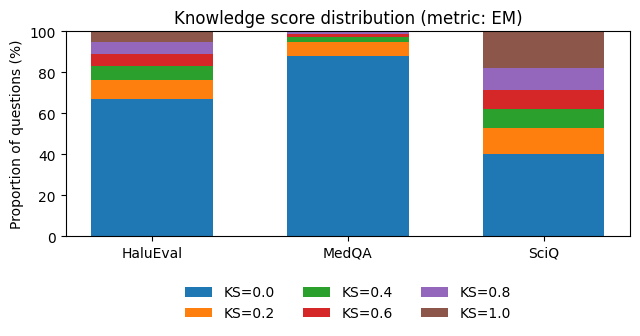

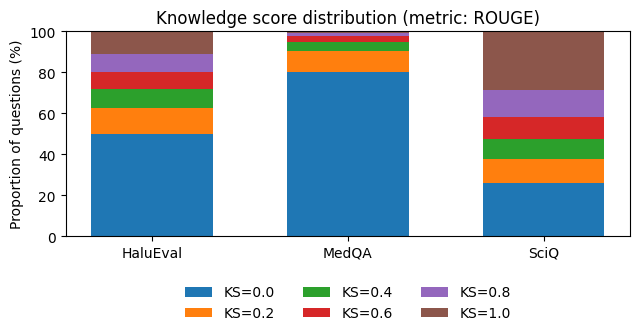

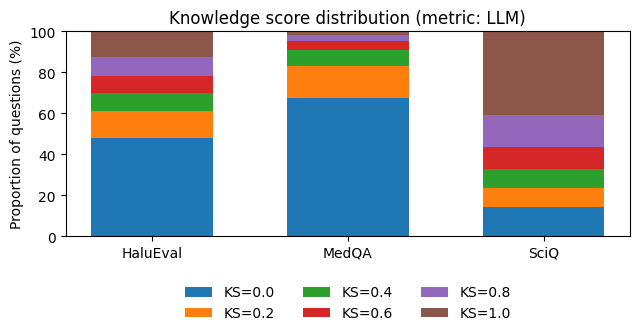

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# KS bins (Table 2 rows)
bins = ["0.0", "0.2", "0.4", "0.6", "0.8", "1.0"]

# Table 2 values (%). 각 리스트는 bins 순서대로.
data = {
    "EM": {
        "HaluEval": [66.75, 9.34, 7.24, 5.85, 5.68, 5.15],
        "MedQA":    [87.98, 6.60, 2.63, 1.56, 0.87, 0.34],
        "SciQ":     [40.00, 12.66, 9.58, 9.21, 10.52, 18.02],
    },
    "ROUGE": {
        "HaluEval": [49.83, 12.59, 9.41, 8.48, 8.76, 10.94],
        "MedQA":    [80.28, 10.26, 4.45, 2.63, 1.58, 0.80],
        "SciQ":     [25.84, 11.97, 9.80, 10.75, 13.21, 28.44],
    },
    "LLM": {
        "HaluEval": [47.74, 13.13, 8.80, 8.55, 9.34, 12.45],
        "MedQA":    [67.34, 15.74, 7.69, 4.75, 2.77, 1.71],
        "SciQ":     [14.38, 9.07, 9.21, 10.79, 15.93, 40.62],
    },
}

datasets = ["HaluEval", "MedQA", "SciQ"]

def plot_stacked(metric: str, outfile: str = None):
    x = np.arange(len(datasets))
    width = 0.62

    fig, ax = plt.subplots(figsize=(6.5, 3.6))

    bottoms = np.zeros(len(datasets))
    for i, b in enumerate(bins):
        vals = [data[metric][ds][i] for ds in datasets]
        ax.bar(x, vals, width, bottom=bottoms, label=f"KS={b}")
        bottoms += np.array(vals)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_ylabel("Proportion of questions (%)")
    ax.set_ylim(0, 100)
    ax.set_title(f"Knowledge score distribution (metric: {metric})")

    # 범례가 길어질 수 있으니 아래처럼 바깥으로 빼는 게 보통 깔끔합니다.
    ax.legend(ncol=3, bbox_to_anchor=(0.5, -0.18), loc="upper center", frameon=False)

    fig.tight_layout()

    if outfile:
        fig.savefig(outfile, bbox_inches="tight")
    plt.show()

# metric별로 그림 생성
plot_stacked("EM",    "table2_em.pdf")
plot_stacked("ROUGE", "table2_rouge.pdf")
plot_stacked("LLM",   "table2_llm.pdf")
